# 01 · Análisis — Pruebas APRENDER y Estadística Educativa

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]
(https://colab.research.google.com/github/santiagoriverti/analisis_pruebas_aprender/blob/main/01_analisis.ipynb)

Consume el dataset consolidado por [`00_consolidacion.ipynb`](00_consolidacion.ipynb).
En **Colab** lee desde *Mi unidad/`pruebas_aprender/parquet`*; en **local**, desde `datos_consolidados/`.

## Qué se puede analizar (y qué no) — comparabilidad

La clave del análisis es que **las dos familias tienen comparabilidad temporal distinta**:

### RA — Relevamiento Anual (2011–2025): *series de tiempo válidas* ✅
Se releva **todos los años con el mismo diseño**, por eso admite series continuas por
`provincia/departamento/sector/ámbito`:
- **Matrícula** (por nivel, sala, año de estudio) · **Trayectoria** (promoción, repitencia, abandono,
  sobreedad) · **Cargos docentes** · **Población** (indígena, discapacidad, alimentación, idiomas) ·
  **Características** (infraestructura: electricidad, agua, conectividad, equipamiento).

### APRENDER (2016–2025): *comparabilidad restringida a cohortes fijas* ⚠️
El operativo **cambia de nivel/grado/cobertura cada año**, así que **no** hay serie continua. Solo se
compara dentro de la **misma `(nivel, grado, cobertura)`**:
- **Primaria 6° grado – Censal:** 2021 → 2023 → 2025 (Lengua, Matemática).
- **Secundaria 5-6° año – Censal:** 2019 → 2022 → 2024 (Lengua, Matemática).
- El resto (2016–2018, muestrales, Primaria 3°) → análisis **transversal** (un año), no serie.
- La escala de desempeño es homogénea (4 niveles) **salvo Primaria 3° 2024** (Lector incipiente / Nivel I–V).

Variables APRENDER analizables (transversal o dentro de una cohorte fija):
- **Desempeño** (% por nivel) por jurisdicción/sector/ámbito · **Brechas** (Estatal vs Privado,
  Urbano vs Rural) · **Contexto**: NSE (quintiles), nivel educativo del hogar, y las preguntas de contexto.

### Puente RA ↔ APRENDER 🔗
Comparten las claves `provincia/departamento/sector/ámbito`, así que se pueden **cruzar por geografía**
en los años que hay APRENDER (relacionar infraestructura/trayectoria de RA con el desempeño de APRENDER).

---
## 0 · Setup y carga del dataset consolidado

In [1]:
import os, re, sys, subprocess, unicodedata
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

def in_colab():
    try:
        import google.colab  # noqa
        return True
    except ImportError:
        return False

if in_colab():
    from google.colab import drive
    drive.mount('/content/drive')
    OUT = '/content/drive/MyDrive/pruebas_aprender/parquet'
else:
    OUT = os.path.join(os.getcwd(), 'datos_consolidados')

assert os.path.isdir(os.path.join(OUT, 'aprender_long')), (
    f'No encuentro el dataset en {OUT}. Corré primero 00_consolidacion.ipynb '
    '(en Colab guarda en Mi unidad/pruebas_aprender).')
print('Leyendo datos consolidados de:', OUT)

Leyendo datos consolidados de: C:\Users\sriverti\Desktop\INECO\Repositorios\analisis_pruebas_aprender\datos_consolidados


---
## 1 · Funciones de carga y análisis

In [2]:
# ---- Carga ----
def cargar_ra(base):
    return pd.read_parquet(os.path.join(OUT, 'ra', f'ra_{base}.parquet'))

def cargar_aprender(anio=None, cols=None):
    path = os.path.join(OUT, 'aprender_long')
    if anio is None:
        return pd.read_parquet(path, columns=cols)
    return pd.read_parquet(os.path.join(path, f'anio={anio}'), columns=cols)

# ---- Desempeño: armonización de niveles (escala de 4) ----
ORDEN4 = ['Por debajo del básico', 'Básico', 'Satisfactorio', 'Avanzado']
def _n(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode().lower()
    return re.sub(r'[^a-z0-9]+', ' ', s).strip()
def harmonizar_nivel(opcion):
    t = _n(opcion)
    if 'por debajo' in t: return 'Por debajo del básico'
    if t == 'basico': return 'Básico'
    if 'satisfactorio' in t: return 'Satisfactorio'
    if 'avanzado' in t: return 'Avanzado'
    return None  # escala distinta (Primaria 3° 2024) u otra

def cargar_desempeno(anio):
    d = cargar_aprender(anio)
    d = d[d.tipo_variable == 'desempeño'].copy()
    d['nivel_desemp'] = d['variable'].str.split('_', n=1).str[1].map(harmonizar_nivel)
    d['anio'] = anio
    return d

def desempeno_pct(df, group_cols):
    """% de estudiantes por nivel de desempeño (escala 4) dentro de cada grupo."""
    d = df.dropna(subset=['nivel_desemp'])
    t = (d.groupby(list(group_cols) + ['nivel_desemp'], observed=True)['valor'].sum()
           .unstack('nivel_desemp').reindex(columns=ORDEN4))
    return t.div(t.sum(axis=1), axis=0) * 100

# ---- Normalización geográfica para cruces RA↔APRENDER ----
CROSSWALK_PROV = {
    'CIUDAD AUTONOMA DE BUENOS AIRES': 'CIUDAD DE BUENOS AIRES',
    'TIERRA DEL FUEGO, ANTARTIDA E ISLAS DEL ATLANTICO SUR': 'TIERRA DEL FUEGO',
}
def norm_geo(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode().upper()
    return re.sub(r'\s+', ' ', s).strip()
print('Funciones listas.')

Funciones listas.


---
## 2 · Mapa de comparabilidad (cohortes APRENDER con desempeño)
Matriz `(nivel, grado, cobertura, área) × año`. Cada `X` es un operativo medido; las **filas con
varias X en la misma cobertura** son las series comparables en el tiempo.

In [3]:
filas = []
for a in sorted(os.listdir(os.path.join(OUT, 'aprender_long'))):
    anio = int(a.split('=')[1])
    d = cargar_aprender(anio, cols=['cobertura','nivel','grado','area','tipo_variable'])
    dd = d[d.tipo_variable == 'desempeño']
    for k, g in dd.groupby(['nivel','grado','cobertura','area'], observed=True):
        filas.append((*k, anio))
mapa = pd.DataFrame(filas, columns=['nivel','grado','cobertura','area','anio'])
piv = (mapa.assign(x='X').pivot_table(index=['nivel','grado','cobertura','area'],
        columns='anio', values='x', aggfunc='first', observed=True).fillna(''))
piv

anio                                                         2016 2017 2018  \
nivel           grado           cobertura area                                
No especificado No especificado Censal    Lengua                          X   
                                          Matematica                      X   
Primaria        3 grado         Muestral  Lengua                              
                3grado          Muestral  Lengua                X             
                                          Matematica            X             
                6 grado         Censal    Lengua                              
                                          Matematica                          
                                Muestral  Lengua                              
                                          Matematica                          
                No especificado Censal    Ciencias Naturales         X        
                                          Ciencias Sociales          X        
                                          Lengua                X             
                                          Matematica            X             
Secundaria      2-3 año         Muestral  Lengua                X             
                                          Matematica            X             
                5-6 año         Censal    Lengua                              
                                          Matematica                          
                                Muestral  Ciencias Naturales                  
                                          Ciudadania                          
                No especificado Censal    Ciencias Naturales    X             
                                          Ciencias Sociales     X             
                                          Lengua                X    X        
                                          Matematica            X    X        

anio                                                         2019 2021 2022  \
nivel           grado           cobertura area                                
No especificado No especificado Censal    Lengua                              
                                          Matematica                          
Primaria        3 grado         Muestral  Lengua                              
                3grado          Muestral  Lengua                              
                                          Matematica                          
                6 grado         Censal    Lengua                     X        
                                          Matematica                 X        
                                Muestral  Lengua                          X   
                                          Matematica                      X   
                No especificado Censal    Ciencias Naturales                  
                                          Ciencias Sociales                   
                                          Lengua                              
                                          Matematica                          
Secundaria      2-3 año         Muestral  Lengua                              
                                          Matematica                          
                5-6 año         Censal    Lengua                X         X   
                                          Matematica            X         X   
                                Muestral  Ciencias Naturales    X             
                                          Ciudadania            X             
                No especificado Censal    Ciencias Naturales                  
                                          Ciencias Sociales                   
                                          Lengua                              
                                          Matematica                          

anio                                            

---
## 3 · Track A — RA: series de tiempo (2011–2025)
La familia RA admite series continuas. Ejemplo: matrícula de nivel primario por año.

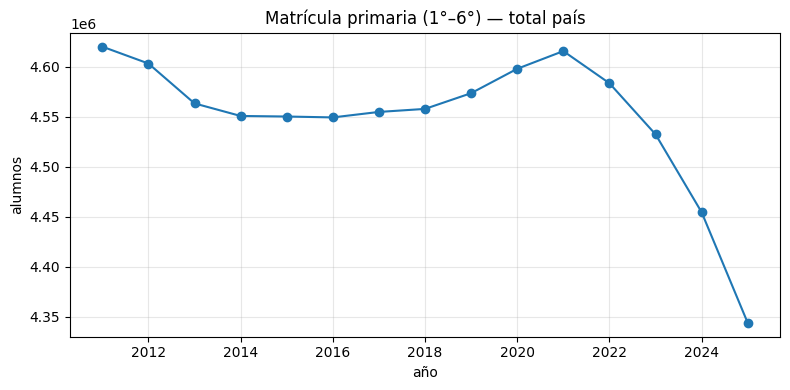

anio
2011    4620306
2012    4603422
2013    4563491
2014    4550923
2015    4550365
2016    4549467
2017    4554952
2018    4557986
2019    4573721
2020    4598149
2021    4615855
2022    4583681
2023    4532553
2024    4454540
2025    4343776
dtype: int64

In [4]:
mat = cargar_ra('matricula')
cols_prim = [c for c in mat.columns if re.fullmatch(r'_[1-6]', c)]   # 1° a 6° grado
serie = mat.groupby('anio')[cols_prim].sum().sum(axis=1)
ax = serie.plot(marker='o', figsize=(8,4), title='Matrícula primaria (1°–6°) — total país')
ax.set_xlabel('año'); ax.set_ylabel('alumnos'); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
serie.astype(int)

---
## 4 · Track B — APRENDER: cohortes comparables
Solo dentro de la misma `(nivel, grado, cobertura)`. Ejemplo: **Primaria 6° Censal** (2021/2023/2025).

Primaria 6° Censal — Lengua — % por nivel:


nivel_desemp,Por debajo del básico,Básico,Satisfactorio,Avanzado
anio,,,,
2021,9.6,19.5,36.8,34.1
2023,11.9,21.6,37.4,29.0
2025,4.9,18.2,44.1,32.8


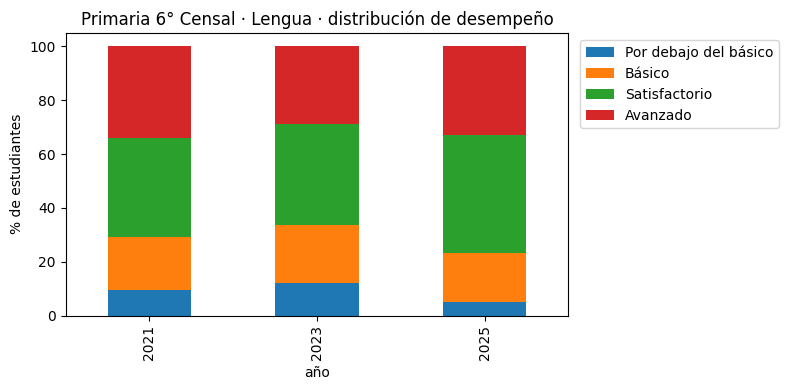

In [5]:
def serie_cohorte(nivel, grado, cobertura, area, anios):
    df = pd.concat([cargar_desempeno(a) for a in anios], ignore_index=True)
    coh = df[(df.nivel==nivel)&(df.grado==grado)&(df.cobertura==cobertura)&(df.area==area)]
    return desempeno_pct(coh, ['anio'])

serie_leng = serie_cohorte('Primaria','6 grado','Censal','Lengua', [2021,2023,2025])
print('Primaria 6° Censal — Lengua — % por nivel:'); display(serie_leng.round(1))
ax = serie_leng.plot(kind='bar', stacked=True, figsize=(8,4),
     title='Primaria 6° Censal · Lengua · distribución de desempeño')
ax.set_xlabel('año'); ax.set_ylabel('% de estudiantes'); ax.legend(bbox_to_anchor=(1.01,1))
plt.tight_layout(); plt.show()

---
## 5 · Track C — Brechas dentro de un año
Comparaciones transversales que **no** requieren comparabilidad temporal: por sector y por ámbito.

Secundaria 5-6° Censal · Matemática 2024 · % por nivel según sector:


nivel_desemp,Por debajo del básico,Básico,Satisfactorio,Avanzado,Satisf+Avanzado
sector,,,,,
Estatal,62.2,25.8,11.9,0.1,11.9
Privado,38.7,32.4,28.7,0.3,29.0


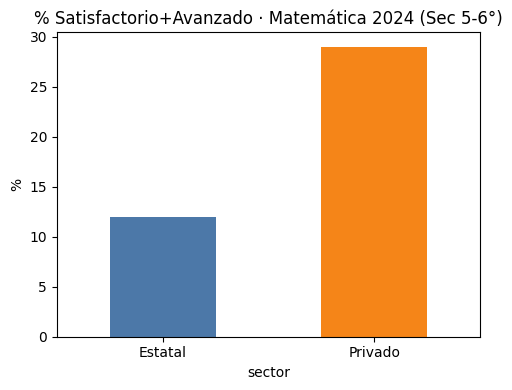

In [6]:
d24 = cargar_desempeno(2024)
coh = d24[(d24.nivel=='Secundaria')&(d24.grado=='5-6 año')&(d24.cobertura=='Censal')&(d24.area=='Matematica')]
por_sector = desempeno_pct(coh, ['sector'])
por_sector['Satisf+Avanzado'] = por_sector[['Satisfactorio','Avanzado']].sum(axis=1)
print('Secundaria 5-6° Censal · Matemática 2024 · % por nivel según sector:')
display(por_sector.round(1))
ax = por_sector['Satisf+Avanzado'].plot(kind='bar', figsize=(5,4), color=['#4C78A8','#F58518'],
     title='% Satisfactorio+Avanzado · Matemática 2024 (Sec 5-6°)')
ax.set_ylabel('%'); ax.set_xlabel('sector'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

---
## 6 · Track D — Cruce RA ↔ APRENDER (por geografía)
Se relaciona el desempeño APRENDER con una variable RA del **mismo año**, uniendo por
`provincia/departamento`. Ejemplo: **% gestión privada** (RA, matrícula) vs **% Satisfactorio+Avanzado**
(APRENDER, Primaria 6° 2023 Lengua) a nivel departamento.

Departamentos cruzados: 271 | correlación = 0.552


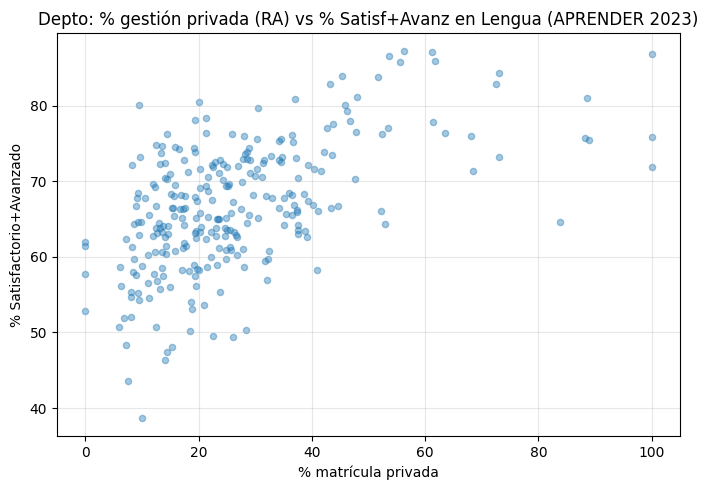

In [7]:
# APRENDER 2023 Primaria 6° Censal Lengua -> % Satisf+Avanz por depto
d23 = cargar_desempeno(2023)
coh = d23[(d23.nivel=='Primaria')&(d23.grado=='6 grado')&(d23.cobertura=='Censal')&(d23.area=='Lengua')].copy()
coh['prov'] = coh.jurisdiccion.map(norm_geo).replace(CROSSWALK_PROV); coh['dep'] = coh.departamento.map(norm_geo)
pct = desempeno_pct(coh, ['prov','dep'])
ap = (pct[['Satisfactorio','Avanzado']].sum(axis=1)).rename('pct_SA').reset_index()

# RA matrícula 2023 -> % privado (primaria) por depto
mat23 = cargar_ra('matricula'); mat23 = mat23[mat23.anio==2023].copy()
pc = [c for c in mat23.columns if re.fullmatch(r'_[1-6]', c)]; mat23['prim'] = mat23[pc].sum(axis=1)
mat23['prov'] = mat23.provincia.map(norm_geo); mat23['dep'] = mat23.departamento.map(norm_geo)
tot = mat23.groupby(['prov','dep'], observed=True)['prim'].sum()
priv = mat23[mat23.sector=='Privado'].groupby(['prov','dep'], observed=True)['prim'].sum()
ra = (100*priv/tot).rename('pct_privado').reset_index()

j = ap.merge(ra, on=['prov','dep'], how='inner').dropna()
print(f'Departamentos cruzados: {len(j)} | correlación = {j.pct_privado.corr(j.pct_SA):.3f}')
ax = j.plot.scatter('pct_privado','pct_SA', alpha=.4, figsize=(7,5),
     title='Depto: % gestión privada (RA) vs % Satisf+Avanz en Lengua (APRENDER 2023)')
ax.set_xlabel('% matrícula privada'); ax.set_ylabel('% Satisfactorio+Avanzado'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

---
## Cómo extender

- **Diccionario:** `pd.read_parquet(f'{OUT}/diccionario_aprender.parquet')` da el texto de cada
  `variable` (pregunta + opción). Útil para analizar preguntas de contexto puntuales.
- **Otras cohortes comparables:** `serie_cohorte('Secundaria','5-6 año','Censal','Matematica',[2019,2022,2024])`.
- **NSE / nivel educativo del hogar:** filtrar `tipo_variable in ('nse','nivel_educativo_hogar')` y
  cruzar con desempeño dentro del mismo operativo.
- **Más RA:** trayectoria (repitencia/abandono), cargos docentes, características (infraestructura).

> Recordatorio de unidades: APRENDER = conteos **ponderados** (se convierten a % dividiendo por el total
> de la celda); RA = conteos **absolutos**. No comparar cohortes APRENDER de distinto grado/nivel entre sí.